# XNES vs CMA-ES on COCO BBOB

This notebook runs both optimizers on the full COCO `bbob` suite with default optimizer settings and COCO-style budgeting.

- XNES: `src.optimizer.Optimizer()` defaults
- CMA-ES: `cma.CMAEvolutionStrategy` defaults (except `sigma0`, which CMA requires explicitly)
- Budget per problem instance: `budget_multiplier * dimension`


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import cma
import cocoex
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import Optimizer

warnings.filterwarnings('ignore', category=RuntimeWarning)


In [2]:
# COCO experiment settings (algorithm settings remain defaults).
SUITE_NAME = 'bbob'
SUITE_INSTANCE = ''
SUITE_OPTIONS = ''
BUDGET_MULTIPLIER = 250
SIGMA0_CMA = 2.0  # required constructor arg for CMA-ES

OUTPUT_ROOT = Path('exdata')  # COCO writes under this root automatically


In [3]:
def run_xnes(problem: cocoex.Problem, budget: int) -> None:
    x0 = np.asarray(problem.initial_solution, dtype=float)
    optimizer = Optimizer()
    params = [optimizer.add(f'x{i:04d}', loc=float(v)) for i, v in enumerate(x0)]

    while problem.evaluations < budget and not problem.final_target_hit:
        x = np.asarray([param.value for param in params], dtype=float)
        value = float(problem(x))
        optimizer.tell(-value)


def run_cma(problem: cocoex.Problem, budget: int, sigma0: float = SIGMA0_CMA) -> None:
    x0 = np.asarray(problem.initial_solution, dtype=float)
    es = cma.CMAEvolutionStrategy(x0, sigma0)

    while not es.stop() and problem.evaluations < budget and not problem.final_target_hit:
        remaining = budget - problem.evaluations
        if remaining < es.popsize:
            break
        candidates = es.ask()
        values = [float(problem(x)) for x in candidates]
        es.tell(candidates, values)


In [4]:
def benchmark(label: str, runner) -> pd.DataFrame:
    suite = cocoex.Suite(SUITE_NAME, SUITE_INSTANCE, SUITE_OPTIONS)
    observer = cocoex.Observer(SUITE_NAME, f'result_folder: {label}')
    rows = []

    for problem in suite:
        problem.observe_with(observer)
        budget = BUDGET_MULTIPLIER * problem.dimension
        start_evals = int(problem.evaluations)

        runner(problem, budget)

        rows.append({
            'optimizer': label,
            'problem_id': problem.id,
            'function': int(problem.id_function),
            'instance': int(problem.id_instance),
            'dimension': int(problem.dimension),
            'evaluations': int(problem.evaluations - start_evals),
            'budget': int(budget),
            'target_hit': bool(problem.final_target_hit),
            'best_f': float(problem.best_observed_fvalue1),
        })

        problem.free()

    suite.free()
    return pd.DataFrame(rows)


In [5]:
xnes_df = benchmark('xnes_default', run_xnes)
cma_df = benchmark('cma_default', run_cma)
results = pd.concat([xnes_df, cma_df], ignore_index=True)

results.head()


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=936068, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=878968, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=890877, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=908995, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=971764, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=945791, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=969667, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=958578, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=969642, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=918010, Sat Mar  7 01:20:50 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=943223, Sat Mar  7 01:20:50 2026)
(3_w,6)-aC

,optimizer,problem_id,function,instance,dimension,evaluations,budget,target_hit,best_f
0,xnes_default,bbob_f001_i01_d02,1,1,2,301,500,True,79.48
1,xnes_default,bbob_f001_i02_d02,1,2,2,329,500,True,394.48
2,xnes_default,bbob_f001_i03_d02,1,3,2,267,500,True,-247.11
3,xnes_default,bbob_f001_i04_d02,1,4,2,265,500,True,-152.04
4,xnes_default,bbob_f001_i05_d02,1,5,2,334,500,True,-25.25


In [6]:
summary = (
    results.groupby(['optimizer', 'dimension'], as_index=False)
    .agg(
        success_rate=('target_hit', 'mean'),
        median_best_f=('best_f', 'median'),
        median_evals=('evaluations', 'median'),
        n=('problem_id', 'count'),
    )
)
summary


,optimizer,dimension,success_rate,median_best_f,median_evals,n
0,cma_default,2,0.419444,2.120000,498.0,360
1,cma_default,3,0.294444,2.772222,749.0,360
2,cma_default,5,0.172222,3.671837,1248.0,360
3,cma_default,10,0.102778,8.172003,2500.0,360
4,cma_default,20,0.086111,31.117246,4992.0,360
5,cma_default,40,0.086111,53.979582,9990.0,360
6,xnes_default,2,0.319444,2.560324,500.0,360
7,xnes_default,3,0.236111,3.349429,750.0,360
8,xnes_default,5,0.172222,4.805515,1250.0,360
9,xnes_default,10,0.097222,5.433752,2500.0,360


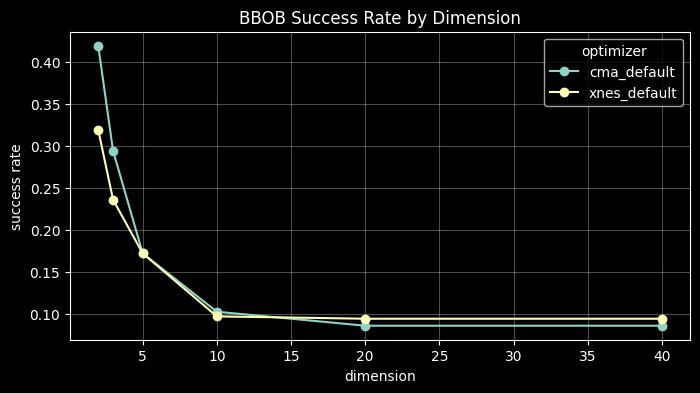

In [7]:
pivot = summary.pivot(index='dimension', columns='optimizer', values='success_rate').sort_index()
ax = pivot.plot(marker='o', figsize=(8, 4), title='BBOB Success Rate by Dimension')
ax.set_ylabel('success rate')
ax.set_xlabel('dimension')
ax.grid(True, alpha=0.3)
plt.show()


In [9]:
# Optional COCO post-processing report (HTML)
import cocopp
cocopp.main([str(OUTPUT_ROOT / 'xnes_default'), str(OUTPUT_ROOT / 'cma_default')])


Post-processing (2 datasets, cocopp2.8.2, Sat Mar  7 01:26:38 2026)
  Using 2 data sets:
    exdata\xnes_default
    exdata\cma_default

Post-processing (2+)
  loading data...


C:\Users\volke\PycharmProjects\xnes\.venv\Lib\site-packages\cocopp\pproc.py:1632: UserWarning: settings is an additional attribute.
  warnings.warn("%s is an additional attribute." % (attrname))


  Data consistent according to consistency_check() in pproc.DataSet
  Data consistent according to consistency_check() in pproc.DataSet
  done (Sat Mar  7 01:26:40 2026).
  Will generate output data in folder ppdata\xnes__cma_d_030701h2640
    this might take several minutes.
ECDF runlength ratio graphs...
  done (Sat Mar  7 01:26:45 2026).
ECDF runlength graphs...
  done (Sat Mar  7 01:26:48 2026).
ECDF graphs per noise group...
Loading best algorithm data from refalgs/best2009-bbob.tar.gz ...
    archive extracted to folder C:\Users\volke\PycharmProjects\xnes\.venv\Lib\site-packages\cocopp\refalgs\.extracted_best2009-bbob ...
  Data consistent according to consistency_check() in pproc.DataSet
  done (Sat Mar  7 01:26:49 2026).
  done (Sat Mar  7 01:26:57 2026).
ECDF graphs per function group...
  done (Sat Mar  7 01:27:13 2026).
ECDF graphs per function...
  done (Sat Mar  7 01:28:16 2026).
Generating comparison tables...
  done (Sat Mar  7 01:28:17 2026).
Scatter plots...
  done (Sa

DictAlg([(('xnes_default', ''),
          [DataSet(xnes_default on f1 2-D, settings = ),
           DataSet(xnes_default on f2 2-D, settings = ),
           DataSet(xnes_default on f3 2-D, settings = ),
           DataSet(xnes_default on f4 2-D, settings = ),
           DataSet(xnes_default on f5 2-D, settings = ),
           DataSet(xnes_default on f6 2-D, settings = ),
           DataSet(xnes_default on f7 2-D, settings = ),
           DataSet(xnes_default on f8 2-D, settings = ),
           DataSet(xnes_default on f9 2-D, settings = ),
           DataSet(xnes_default on f10 2-D, settings = ),
           DataSet(xnes_default on f11 2-D, settings = ),
           DataSet(xnes_default on f12 2-D, settings = ),
           DataSet(xnes_default on f13 2-D, settings = ),
           DataSet(xnes_default on f14 2-D, settings = ),
           DataSet(xnes_default on f15 2-D, settings = ),
           DataSet(xnes_default on f16 2-D, settings = ),
           DataSet(xnes_default on f17 2-D, setti